In [15]:
%matplotlib inline
import math
import time
import numpy as np
import torch
import d2l
import time
import random

In [3]:
n = 10000
a = torch.ones([n])
b = torch.ones([n])
a , b

(tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 tensor([1., 1., 1.,  ..., 1., 1., 1.]))

In [4]:
class Timer: #@save
    """记录多次运行时间"""
    def __init__(self):
        self.times = []
        self.start()

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self): #Python 官方的列表只有 append、pop、sort 这些基础功能，没有cumsum()
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()
        

In [5]:
c = torch.zeros(n)
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
print(f'{timer.stop():.5f} sec')

0.03017 sec


In [6]:
timer.start() #因为上面stop了，所以必须重新开始
d = a + b
print(f'{timer.stop():.5f} sec')

0.00012 sec


In [9]:
def normal(x, mu, sigma):
    p = 1/math.sqrt(2 * math.pi * sigma **2)
    return p * np.exp(-0.5/sigma **2 * (x -mu)**2)

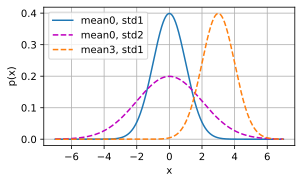

In [14]:
#再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)

# 均值和标准差化
params = [(0,1), (0,2), (3,1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x', ylabel='p(x)', figsize=(4.5, 2.5),
        legend=[f'mean{mu}, std{sigma}' for mu, sigma in params])

In [ ]:
def synthetic_data(w, b, num_examples): #@save
    """生成y=Xw+b+噪声"""
    X = torch.normal(0, 1, (num_examples, len(w))) #len(w) 代表了你这个回归模型中“输入特征的个数”（即因变量的维度）
    y = torch.matmul(X, w) + b #矩阵乘法，维度会发生变化
    y += torch.normal(0, 0.01, y.shape) #加噪音
    return X, y.reshape((-1, 1)) #-1 代表让系统自动去算行数（系统自动填入 1000）,1 代表固定为 1 列，为了防止反向传播疯狂复制导致计算爆炸

true_w = torch.tensor([2, -3.4])
true_b = 4.2
features, labels = synthetic_data(true_w, true_b, 1000)


In [19]:
features[0], labels[0]

(tensor([ 1.2448, -0.7862]), tensor([9.3774]))

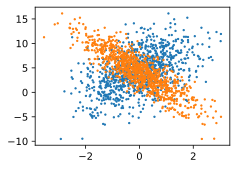

In [24]:
d2l.set_figsize()
d2l.plt.scatter(features[:, 0].detach().numpy(), labels.detach().numpy(), 2)
d2l.plt.scatter(features[:, 1].detach().numpy(), labels.detach().numpy(), 2)

In [ ]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # 这些样本是随机读取的，没有特定的顺序
    random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i: min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]
        #return 是“一次性全打包带走”，而 yield 是“吃自助餐，吃多少拿多少（迭代器）

In [ ]:
batch_size = 10
for X, y in data_iter(batch_size, features, labels):
    print(X, '\n', y)
    break #这里的 break 导致程序只取了第一个 Batch，然后就立刻结束了

tensor([[-0.0345,  1.8334],
        [ 0.5732,  1.9453],
        [-1.7758,  0.6900],
        [ 0.9798,  0.1552],
        [ 0.0663,  0.7516],
        [ 0.4906, -0.2419],
        [-0.4517,  0.3444],
        [ 0.0791, -1.5542],
        [ 0.7063, -0.1540],
        [-1.8856, -0.2577]]) 
 tensor([[-2.1088],
        [-1.2830],
        [-1.7049],
        [ 5.6375],
        [ 1.7681],
        [ 6.0171],
        [ 2.1155],
        [ 9.6440],
        [ 6.1322],
        [ 1.3103]])


In [28]:
# 初始化模型参数
w = torch.normal(0, 0.01, size=(2,1), requires_grad=True)
b = torch.zeros(1, requires_grad=True)
w, b

(tensor([[ 0.0088],
         [-0.0142]], requires_grad=True),
 tensor([0.], requires_grad=True))

In [30]:
#定义模型
def linreg(X, w, b):
    """线性回归模型"""
    return torch.matmul(X, w) + b
#定义损失函数
def squared_loss(y_hat, y):
    return (y_hat-y) **2/2

部门一：反向传播（Backpropagation）—— 负责“算”
loss.backward()  # 👈 这才是真正的反向传播！
- 它在干什么：PyTorch 顺着我们之前聊过的“隐形录像带（计算图）”，从最后的损失 loss 开始，利用微积分的链式法则，一路往回倒推，计算出每个参数的梯度。
- 它的产物：它把算出来的结果安安静静地存放在了每一个参数的 .grad 属性里。此时，参数（比如 w 和 b）的值纹丝不动，根本没有变，只是它们身上多了一堆被称为“梯度”的数字。

部门二：梯度下降优化器（SGD） —— 负责“用”
- 它在干什么：此时，反向传播已经彻底结束，录像机也已经关了（with torch.no_grad():）。这个函数纯粹是一个执行者。
- 它的产物：它直接去读取刚才反向传播存放在 param.grad 里的数字，顺着这个方向把参数的值减掉一点（param -= ...），从而完成了真正改变参数数值的动作。

In [ ]:
# 反向传播负责“算”梯度，而 SGD 负责“用”梯度
def sgd(params, lr, batch_size):
    """小批量随机梯度下降"""
    with torch.no_grad(): #PyTorch 默认长了一双“复眼”，只要你对 Tensor 进行任何数学运算（比如加减乘除），它就会自动开启隐形录像带把过程记录在计算图里，用来算梯度。
        #如果我们不把 PyTorch 的监控关掉，PyTorch 就会把“更新权重的数学公式”也记录到下一轮的梯度计算中去，导致计算图无限膨胀，内存直接爆炸！
        for param in params:
            param -= lr * param.grad / batch_size
            param.grad.zero_() #param.grad.zero_() 后面的下划线 _ 在 PyTorch 里代表 In-place（原地修改）

In [31]:
lr = 0.03
num_epochs = 3
net = linreg
loss = squared_loss
for epoch in range(num_epochs):
    for X, y in data_iter(batch_size, features, labels):
        l = loss(net(X, w, b), y) #X和y的小批量损失
        # 因为l形状是(batch_size,1)，而不是一个标量。l中的所有元素被加到一起，并以此计算关于[w,b]的梯度
        l.sum().backward()
        sgd([w, b], lr, batch_size) #使用参数的梯度分别更新w和b
    with torch.no_grad():
        train_l = loss(net(features, w, b), labels)
        print(f'epoch {epoch + 1}, loss {float(train_l.mean()):f}')
        

epoch 1, loss 0.037480
epoch 2, loss 0.000138
epoch 3, loss 0.000051


带括号 linreg()：代表“立刻执行这个函数”。如果这里写成 net = linreg()，Python 会马上运行它，然后把函数运行完返回的最终结果赋给 net。但因为你现在连输入数据 X, w, b 都没传进去，直接执行必然会报错。

不带括号 linreg：代表“给这个函数起个别名（传递函数指针）”。Python 允许把函数当成一个普通的变量传来传去。这一步的意思是：“我把 linreg 这个函数本身，打包贴上了一个叫 net 的新标签。”